In [1]:
import pandas as pd
from pathlib import Path

HI_ACCOUNT_DATA_PATH = Path().cwd() / "Data-HI" / "HI-Small_accounts.csv"
HI_TRANSACTIONS_DATA_PATH = Path().cwd() / "Data-HI" / "HI-Small_Trans.csv"

accounts_df = pd.read_csv(HI_ACCOUNT_DATA_PATH)
trans_df = pd.read_csv(HI_TRANSACTIONS_DATA_PATH)

In [2]:
accounts_df.head()

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [3]:
trans_df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [ ]:
print(accounts_df.shape)
print(trans_df.shape)
print("-----------------------------------")
print("Types from the accounts data frame:")
print(accounts_df.dtypes)
print("-----------------------------------")
print("Types from the transactions data frame:")
print(trans_df.dtypes)
print("-----------------------------------")



(518581, 5)
(5078345, 11)
-----------------------------------
Types from the accounts data frame:
Bank Name           str
Bank ID           int64
Account Number      str
Entity ID           str
Entity Name         str
dtype: object
-----------------------------------
Types from the transactions data frame:
Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object
-----------------------------------
Amount of null values from the accounts data frame:
Bank Name         0
Bank ID           0
Account Number    0
Entity ID         0
Entity Name       0
dtype: int64
-----------------------------------
Amount of null values from the transactions data frame:
Timestamp             0
From Bank             0
Account

In [ ]:
trans_df["Timestamp"] = pd.to_datetime(trans_df["Timestamp"])
trans_timestamp = trans_df["Timestamp"]
trans_timestamp_hour = trans_timestamp.dt.hour

0           0
1           0
2           0
3           0
4           0
           ..
5078340    23
5078341    23
5078342    23
5078343    23
5078344    23
Name: Timestamp, Length: 5078345, dtype: int32

In [22]:
print( f"""
Oldest transaction:
{min(trans_timestamp)}
------------------------
Most recent transaction:
{max(trans_timestamp)}
""")


Oldest transaction:
2022-09-01 00:00:00
------------------------
Most recent transaction:
2022-09-18 16:18:00



In [26]:
trans_timestamp.groupby(trans_timestamp_hour).size()

Timestamp
0     634726
1     193728
2     193143
3     193249
4     193166
5     193900
6     194456
7     193336
8     192921
9     192952
10    193229
11    193500
12    192972
13    192521
14    192787
15    194871
16    193407
17    193154
18    193321
19    192824
20    192809
21    192192
22    191836
23    193345
Name: Timestamp, dtype: int64

In [28]:
trans_df.groupby([trans_timestamp_hour, "Is Laundering"]).size()

Timestamp  Is Laundering
0          0                634550
           1                   176
1          0                193576
           1                   152
2          0                192978
           1                   165
3          0                193103
           1                   146
4          0                193012
           1                   154
5          0                193712
           1                   188
6          0                194249
           1                   207
7          0                193141
           1                   195
8          0                192663
           1                   258
9          0                192735
           1                   217
10         0                192995
           1                   234
11         0                193205
           1                   295
12         0                192636
           1                   336
13         0                192229
           1                  

In [32]:
trans_df[['Amount Paid', "Amount Received"]].describe().apply(lambda s: s.apply('{0:.2f}'.format))

,Amount Paid,Amount Received
count,5078345.00,5078345.00
mean,4509273.37,5988726.07
std,869772830.92,1037183108.89
min,0.00,0.00
25%,184.48,183.37
50%,1414.54,1411.01
75%,12297.84,12346.27
max,1046302363293.48,1046302363293.48


<Axes: xlabel='Amount Paid', ylabel='Count'>

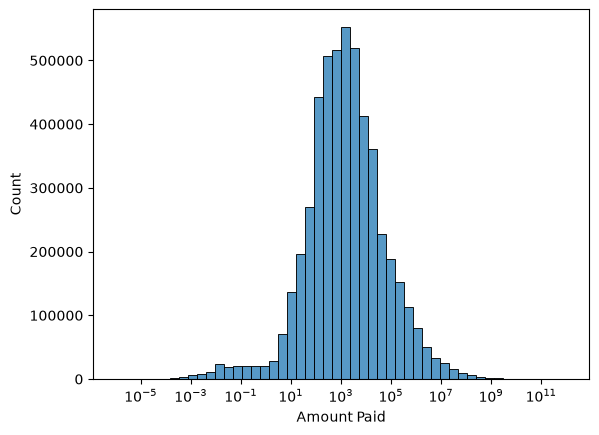

In [33]:
import seaborn as sns

trans_df_amounts = trans_df[trans_df['Amount Paid'] > 0]

sns.histplot(data=trans_df_amounts,x='Amount Paid', log_scale=True, bins=50)

In [40]:
print(f"""
{trans_df['Payment Format'].value_counts()}
--------------------------
{trans_df['Receiving Currency'].value_counts()}
""")




Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64
--------------------------
Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148151
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64



In [41]:
print("Formato de Pagamento vs Fraude")
format_crosstab = pd.crosstab(trans_df['Payment Format'], trans_df['Is Laundering'])
print(format_crosstab)

print("\nMoeda vs Fraude")
currency_crosstab = pd.crosstab(trans_df['Receiving Currency'], trans_df['Is Laundering'])
print(currency_crosstab)

Formato de Pagamento vs Fraude
Is Laundering         0     1
Payment Format               
ACH              596314  4483
Bitcoin          146035    56
Cash             490783   108
Cheque          1864007   324
Credit Card     1323118   206
Reinvestment     481056     0
Wire             171855     0

Moeda vs Fraude
Is Laundering             0     1
Receiving Currency               
Australian Dollar    138384   127
Bitcoin              148095    56
Brazil Real           71487    57
Canadian Dollar      141229   128
Euro                1170645  1372
Mexican Peso         110938    92
Ruble                157228   133
Rupee                191898   167
Saudi Riyal           89597   374
Shekel               194893    95
Swiss Franc          237691   193
UK Pound             181123   132
US Dollar           1877429  1912
Yen                  156164   155
Yuan                 206367   184
